In [22]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [45]:
with open("eval_result/evaluation_result_0.json", "r") as f:
    data = json.load(f)

In [51]:
# data

In [47]:
def func1(name):
    if '2' in name: 
        return 2
    if '5' in name and '1' not in name:
        return 5
    if '10' in name:
        return 10
    return 15

def func2(name):
    if '2' not in name:
        return 2
    if 'x5' not in name:
        return 5
    if '0' not in name:
        return 10
    return 15

d = {}
for key in data:
    d[func2(key)] = data[key]
d

{2: {'x2x2': [36.329891204833984,
   10.16374683380127,
   150.9551239013672,
   70.68340301513672,
   1038.0924072265625],
  'x5x5': [6.0549540519714355,
   4.154122829437256,
   3.5565147399902344,
   4.661320209503174,
   1309.594970703125],
  'x10x10': [17.516334533691406,
   12.311563491821289,
   10.878636360168457,
   14.46422004699707,
   18504.40234375],
  'x15x15': [43.89347457885742,
   28.75748634338379,
   28.002553939819336,
   38.650978088378906,
   260519.28125]},
 5: {'x2x2': [1.507598876953125,
   1.3148207664489746,
   1.3924518823623657,
   3.3152270317077637,
   1.4979655742645264],
  'x5x5': [95.25180053710938,
   828.568603515625,
   197.85171508789062,
   201.40354919433594,
   1313.0848388671875],
  'x10x10': [11.611696243286133,
   11.81467056274414,
   12.644509315490723,
   31.635881423950195,
   11.60106372833252],
  'x15x15': [28.1489315032959,
   31.669231414794922,
   32.678443908691406,
   72.96702575683594,
   32.22355651855469]},
 10: {'x2x2': [1.4166

In [48]:
new_d = {}
for i in d:
    dd = {}
    for j in d[i]:
        dd[func(j)] = d[i][j]
    new_d[i] = dd
new_d

{2: {2: [36.329891204833984,
   10.16374683380127,
   150.9551239013672,
   70.68340301513672,
   1038.0924072265625],
  5: [6.0549540519714355,
   4.154122829437256,
   3.5565147399902344,
   4.661320209503174,
   1309.594970703125],
  10: [17.516334533691406,
   12.311563491821289,
   10.878636360168457,
   14.46422004699707,
   18504.40234375],
  15: [43.89347457885742,
   28.75748634338379,
   28.002553939819336,
   38.650978088378906,
   260519.28125]},
 5: {2: [1.507598876953125,
   1.3148207664489746,
   1.3924518823623657,
   3.3152270317077637,
   1.4979655742645264],
  5: [95.25180053710938,
   828.568603515625,
   197.85171508789062,
   201.40354919433594,
   1313.0848388671875],
  10: [11.611696243286133,
   11.81467056274414,
   12.644509315490723,
   31.635881423950195,
   11.60106372833252],
  15: [28.1489315032959,
   31.669231414794922,
   32.678443908691406,
   72.96702575683594,
   32.22355651855469]},
 10: {2: [1.4166523218154907,
   48.767127990722656,
   1.1939046

In [49]:
# Removing outliers
for i in new_d[2]:
    new_d[2][i].pop(-1)

for i in new_d[10]:
    new_d[10][i].pop(1)
new_d

{2: {2: [36.329891204833984,
   10.16374683380127,
   150.9551239013672,
   70.68340301513672],
  5: [6.0549540519714355,
   4.154122829437256,
   3.5565147399902344,
   4.661320209503174],
  10: [17.516334533691406,
   12.311563491821289,
   10.878636360168457,
   14.46422004699707],
  15: [43.89347457885742,
   28.75748634338379,
   28.002553939819336,
   38.650978088378906]},
 5: {2: [1.507598876953125,
   1.3148207664489746,
   1.3924518823623657,
   3.3152270317077637,
   1.4979655742645264],
  5: [95.25180053710938,
   828.568603515625,
   197.85171508789062,
   201.40354919433594,
   1313.0848388671875],
  10: [11.611696243286133,
   11.81467056274414,
   12.644509315490723,
   31.635881423950195,
   11.60106372833252],
  15: [28.1489315032959,
   31.669231414794922,
   32.678443908691406,
   72.96702575683594,
   32.22355651855469]},
 10: {2: [1.4166523218154907, 1.1939046382904053, 1.4996886253356934],
  5: [4.838229656219482, 4.14333438873291, 4.252002716064453],
  10: [25969

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (3,).

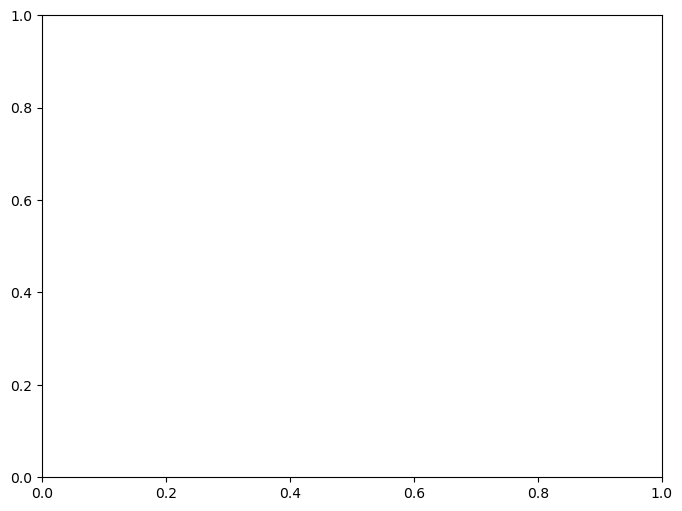

In [50]:
# Define the data
import math
x = [2, 5, 10, 15]
bins = [[xs-0.3, xs-0.1, xs+0.1, xs+0.3] for xs in x]
values = [[math.log(sum(new_d[i][j])/len(new_d[i][j])) for j in new_d[i]] for i in new_d]

# Create the histogram
plt.figure(figsize=(8, 6))

for i, xs, bin in zip(range(4), x, bins):
    plt.bar([b[i] for b in bins], [val[i] for val in values], 0.2, label=str(xs))

# Customize the plot
plt.xlabel("Dataset")
plt.ylabel("Validation loss")
plt.xticks(x)
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.savefig('plot.png')
plt.show()

In [15]:
values

[[-0.7907079708659345,
  8.329948214141384,
  11.32920120609954,
  13.243805023287944],
 [7.778277598857323, 0.8738927414094688, 10.56095667171018, 12.97022012509553],
 [9.833501763604582,
  9.278226415008614,
  2.4952510002610366,
  11.713596093671013],
 [10.820772337051205,
  10.682810870419626,
  10.277098698053063,
  4.9218502448042525]]